# EXP-005 | 피처 Importance 기반 선택

EXP-003 피처 중 importance 하위 피처를 제거하고 성능 비교.

| 항목 | 내용 |
|---|---|
| 기반 실험 | EXP-003 (피처 엔지니어링 v1) |
| 모델 | LightGBM |
| CV | Stratified 5-Fold |

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import lightgbm as lgb

from src.preprocessing import preprocess

warnings.filterwarnings('ignore')
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = Path('../data/raw')
OUT_DIR  = Path('../data/submissions')
DOCS_DIR = Path('../docs')
TARGET   = '임신 성공 여부'
SEED     = 42
N_FOLDS  = 5
EXP_NO   = 5
AUTHOR   = '조여진'
MODEL_NAME = 'LightGBM'
CV_STR   = f'Stratified {N_FOLDS}-Fold'

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
sub   = pd.read_csv(DATA_DIR / 'sample_submission.csv')
print(f'train: {train.shape}  /  test: {test.shape}')

train: (256351, 69)  /  test: (90067, 68)


## 1. 피처 준비 (EXP-003 동일)

In [2]:
def add_pre_encode_features(df):
    df = df.copy()
    df['기증_난자_여부'] = (df['난자 출처'] == '기증 제공').astype(int)
    df['기증_정자_여부'] = df['정자 출처'].isin(['기증 제공', '배우자 및 기증 제공']).astype(int)
    return df

def add_derived_features(df):
    df = df.copy()
    eps = 1e-6
    df['수정률']    = df['총 생성 배아 수']   / (df['혼합된 난자 수'] + eps)
    df['이식률']    = df['이식된 배아 수']    / (df['총 생성 배아 수'] + eps)
    df['저장률']    = df['저장된 배아 수']    / (df['총 생성 배아 수'] + eps)
    df['ICSI_비율'] = df['미세주입된 난자 수'] / (df['혼합된 난자 수'] + eps)
    df['배아_발달일']   = df['배아 이식 경과일'] - df['난자 혼합 경과일']
    df['신선_시술_여부'] = df['수집된 신선 난자 수'].notna().astype(int)
    male_cols   = ['남성 주 불임 원인','남성 부 불임 원인','불임 원인 - 남성 요인']
    female_cols = ['여성 주 불임 원인','여성 부 불임 원인','불임 원인 - 난관 질환',
                   '불임 원인 - 배란 장애','불임 원인 - 자궁내막증','불임 원인 - 자궁경부 문제']
    couple_cols = ['부부 주 불임 원인','부부 부 불임 원인']
    sperm_cols  = ['불임 원인 - 정자 농도','불임 원인 - 정자 운동성',
                   '불임 원인 - 정자 형태','불임 원인 - 정자 면역학적 요인']
    all_cause   = male_cols + female_cols + couple_cols + sperm_cols + ['불명확 불임 원인']
    df['남성_불임_합계']      = df[male_cols].sum(axis=1)
    df['여성_불임_합계']      = df[female_cols].sum(axis=1)
    df['부부_불임_합계']      = df[couple_cols].sum(axis=1)
    df['정자_문제_합계']      = df[sperm_cols].sum(axis=1)
    df['총_불임원인_수']      = df[all_cause].sum(axis=1)
    df['임신시도기록_있음']    = df['임신 시도 또는 마지막 임신 경과 연수'].notna().astype(int)
    df['신선_난자_저장_있음']  = (df['저장된 신선 난자 수'] > 0).astype(int)
    df['나이_시술횟수_상호작용'] = df['시술 당시 나이'] * df['총 시술 횟수']
    return df

train_fe = add_pre_encode_features(train)
test_fe  = add_pre_encode_features(test)
X_train_full, X_test_full = preprocess(train_fe, test_fe)
X_train_full = add_derived_features(X_train_full)
X_test_full  = add_derived_features(X_test_full)
y_train = train[TARGET]
print(f'전체 피처: {X_train_full.shape[1]}개')

전체 피처: 85개


## 2. 전체 피처로 학습 → Importance 추출

In [3]:
LGB_PARAMS = dict(
    objective='binary', metric='auc', verbosity=-1, seed=SEED,
    is_unbalance=True, learning_rate=0.05, num_leaves=127,
    min_child_samples=50, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=1, lambda_l1=0.1, lambda_l2=0.1,
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
importance_gain = np.zeros(X_train_full.shape[1])
oof_full = np.zeros(len(X_train_full))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y_train), 1):
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    ds_tr  = lgb.Dataset(X_tr, label=y_tr)
    ds_val = lgb.Dataset(X_val, label=y_val, reference=ds_tr)
    model  = lgb.train(LGB_PARAMS, ds_tr, num_boost_round=2000,
                       valid_sets=[ds_val],
                       callbacks=[lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(period=-1)])
    oof_full[val_idx] = model.predict(X_val)
    importance_gain  += model.feature_importance(importance_type='gain')

oof_auc_full   = roc_auc_score(y_train, oof_full)
oof_prauc_full = average_precision_score(y_train, oof_full)
oof_f1_full    = f1_score(y_train, (oof_full >= 0.5).astype(int))
importance_gain /= N_FOLDS
importance = pd.Series(importance_gain, index=X_train_full.columns).sort_values(ascending=False)
print(f'전체 피처 OOF AUC: {oof_auc_full:.5f}')

전체 피처 OOF AUC: 0.73864


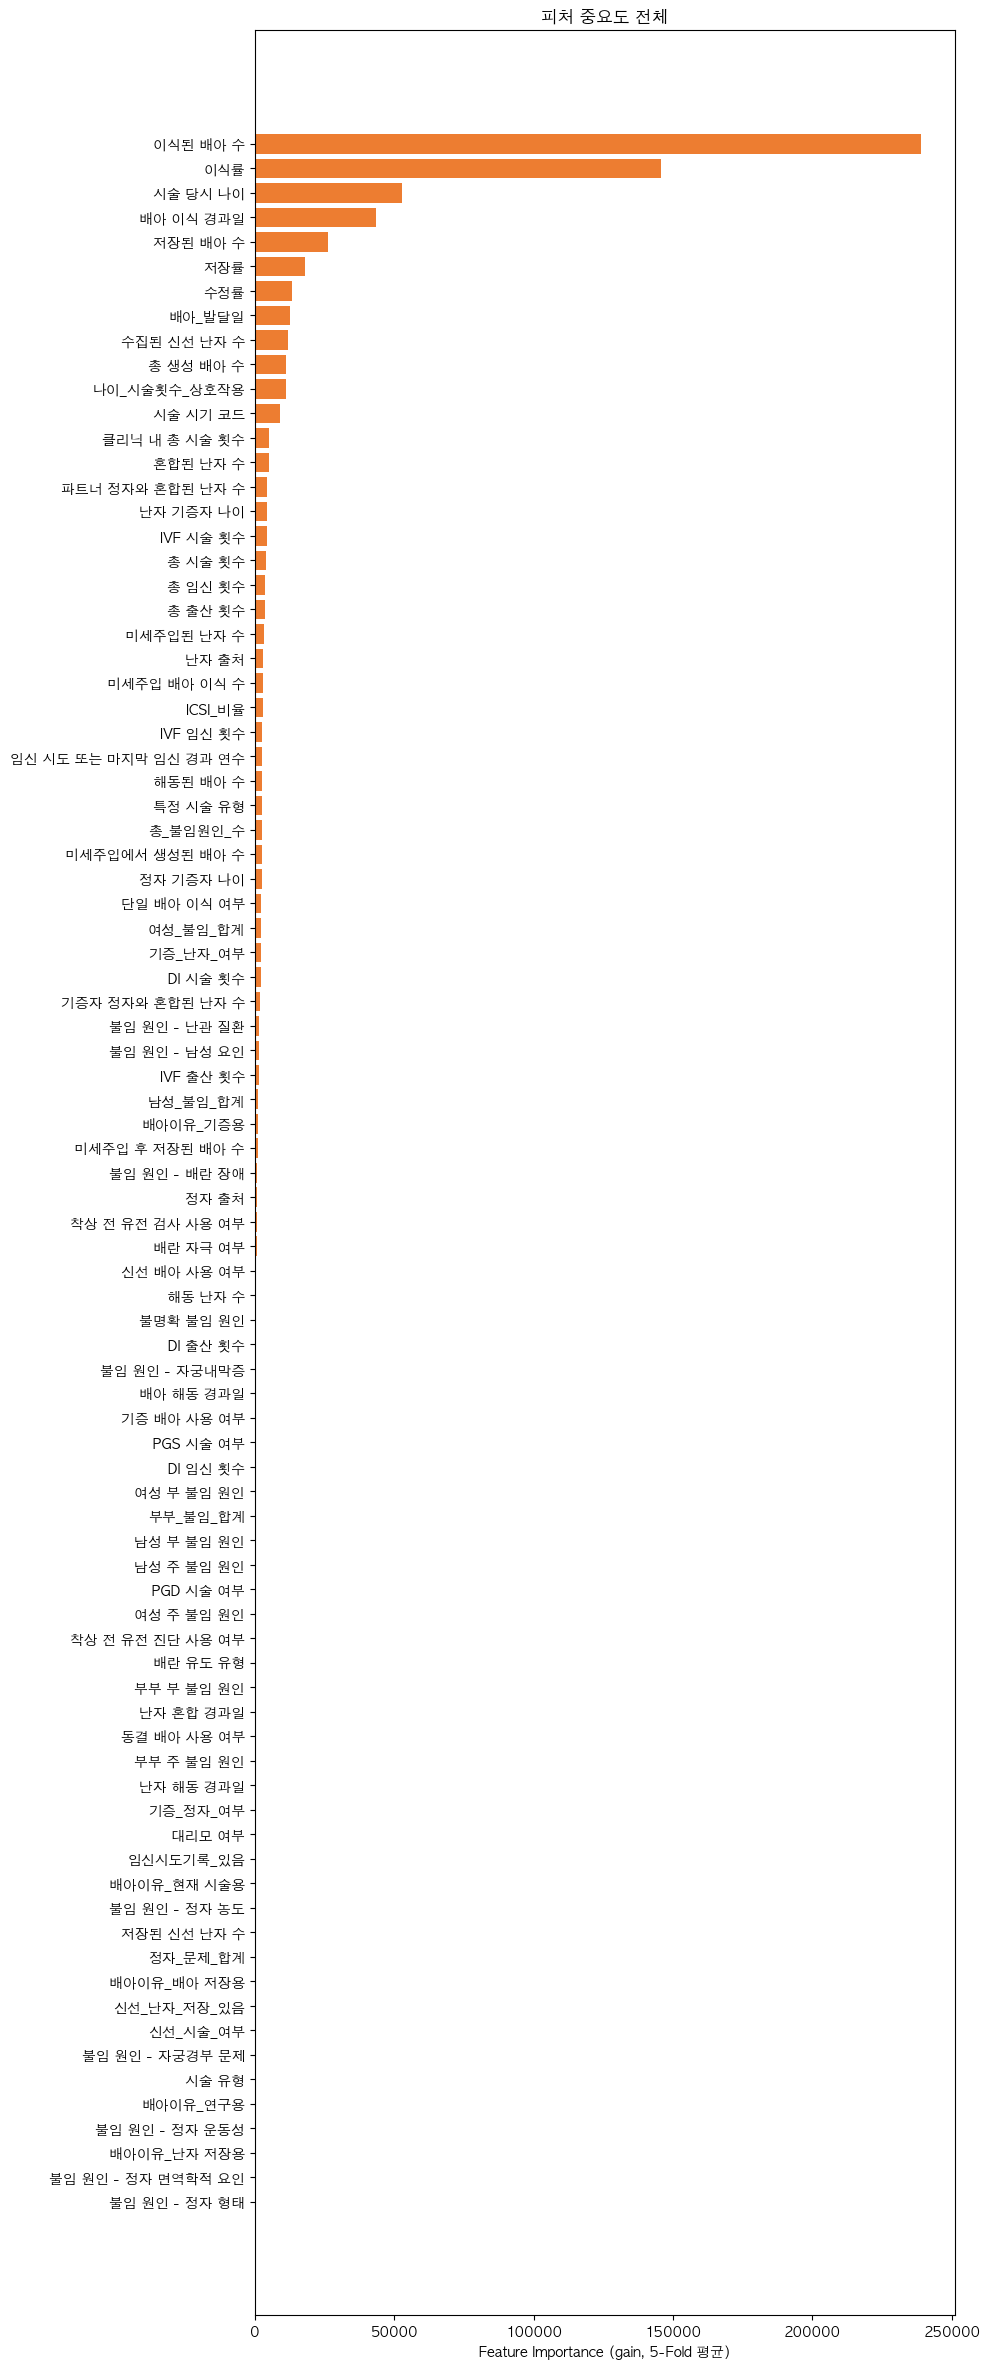


Importance = 0 피처 (8개):
['신선_시술_여부', '불임 원인 - 자궁경부 문제', '시술 유형', '배아이유_연구용', '불임 원인 - 정자 운동성', '배아이유_난자 저장용', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 형태']


In [4]:
# Importance 시각화 + 하위 피처 확인
fig, ax = plt.subplots(figsize=(10, max(6, len(importance) * 0.28)))
colors = ['#ED7D31' if v > 0 else '#C00000' for v in importance[::-1]]
ax.barh(importance.index[::-1], importance.values[::-1], color=colors)
ax.set_xlabel('Feature Importance (gain, 5-Fold 평균)')
ax.set_title('피처 중요도 전체')
plt.tight_layout()
plt.show()

# importance = 0인 피처
zero_imp = importance[importance == 0]
print(f'\nImportance = 0 피처 ({len(zero_imp)}개):')
print(zero_imp.index.tolist())

## 3. 하위 피처 제거 후 재학습

In [5]:
# importance 하위 N개 제거 (0인 것 + 하위 10%)
REMOVE_ZERO   = True   # importance=0 피처 제거
PERCENTILE_CUT = 10    # 하위 N% 추가 제거 (0으로 설정 시 zero만 제거)

remove_cols = set()
if REMOVE_ZERO:
    remove_cols.update(importance[importance == 0].index.tolist())
if PERCENTILE_CUT > 0:
    threshold = np.percentile(importance[importance > 0], PERCENTILE_CUT)
    remove_cols.update(importance[importance <= threshold].index.tolist())

print(f'제거할 피처 ({len(remove_cols)}개): {sorted(remove_cols)}')

X_train_sel = X_train_full.drop(columns=list(remove_cols))
X_test_sel  = X_test_full.drop(columns=list(remove_cols))
print(f'\n선택된 피처 수: {X_train_sel.shape[1]}개 (전체 대비 -{len(remove_cols)}개)')

제거할 피처 (16개): ['대리모 여부', '배아이유_난자 저장용', '배아이유_배아 저장용', '배아이유_연구용', '배아이유_현재 시술용', '불임 원인 - 자궁경부 문제', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '시술 유형', '신선_난자_저장_있음', '신선_시술_여부', '임신시도기록_있음', '저장된 신선 난자 수', '정자_문제_합계']

선택된 피처 수: 69개 (전체 대비 -16개)


In [6]:
skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X_train_sel))
test_preds = np.zeros(len(X_test_sel))
fold_aucs  = []
models     = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_sel, y_train), 1):
    X_tr, X_val = X_train_sel.iloc[tr_idx], X_train_sel.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    ds_tr  = lgb.Dataset(X_tr, label=y_tr)
    ds_val = lgb.Dataset(X_val, label=y_val, reference=ds_tr)
    model  = lgb.train(LGB_PARAMS, ds_tr, num_boost_round=2000,
                       valid_sets=[ds_val],
                       callbacks=[lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(period=-1)])
    val_prob = model.predict(X_val)
    auc = roc_auc_score(y_val, val_prob)
    fold_aucs.append(auc)
    oof_preds[val_idx]  = val_prob
    test_preds         += model.predict(X_test_sel) / N_FOLDS
    models.append(model)
    print(f'  Fold {fold}  best_iter={model.best_iteration:4d}  AUC={auc:.5f}')

oof_auc   = roc_auc_score(y_train, oof_preds)
oof_prauc = average_precision_score(y_train, oof_preds)
oof_f1    = f1_score(y_train, (oof_preds >= 0.5).astype(int))
print(f'\n선택 피처  ROC-AUC : {oof_auc:.5f}   PR-AUC : {oof_prauc:.5f}   F1 : {oof_f1:.5f}')
print(f'전체 피처  ROC-AUC : {oof_auc_full:.5f}   PR-AUC : {oof_prauc_full:.5f}   F1 : {oof_f1_full:.5f}')
print(f'차이 (ROC-AUC)    : {oof_auc - oof_auc_full:+.5f}')

  Fold 1  best_iter=  73  AUC=0.73633
  Fold 2  best_iter= 110  AUC=0.74161
  Fold 3  best_iter=  81  AUC=0.73908
  Fold 4  best_iter=  75  AUC=0.73767
  Fold 5  best_iter=  84  AUC=0.73928

선택 피처  ROC-AUC : 0.73878   PR-AUC : 0.44839   F1 : 0.51637
전체 피처  ROC-AUC : 0.73864   PR-AUC : 0.44874   F1 : 0.51644
차이 (ROC-AUC)    : +0.00014


## 4. Submission 저장 & 실험 기록

In [7]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
sub['probability'] = test_preds
auc_str   = f'{oof_auc:.4f}'.replace('.', '')
out_fname = f'submission_exp{EXP_NO:03d}_{AUTHOR}_{auc_str}.csv'
sub.to_csv(OUT_DIR / out_fname, index=False)
print(f'저장: {OUT_DIR / out_fname}')

저장: ../data/submissions/submission_exp005_yjc_07388.csv


In [8]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from datetime import date

oof_binary = (oof_preds >= 0.5).astype(int)
f1        = f1_score(y_train, oof_binary)
recall    = recall_score(y_train, oof_binary)
precision = precision_score(y_train, oof_binary)
accuracy  = accuracy_score(y_train, oof_binary)

PREPROCESSING_VER = 'v1'
IMBALANCE_METHOD  = 'is_unbalance=True'
SUBMITTED         = 'N'
HACKATHON_SCORE   = None
NOTES             = f'importance 하위 {PERCENTILE_CUT}% 제거, {len(remove_cols)}개 피처 제거'
INSIGHTS          = ''

params_str = (f"num_leaves=127, lr=0.05, feature_fraction=0.8, "
              f"removed={len(remove_cols)}cols")

def log_to_leaderboard(exp_no, author, model_name, params_str,
                        f1, recall, precision, accuracy, oof_auc,
                        cv_strategy, preprocessing_ver, n_features,
                        imbalance_method, submitted, hackathon_score,
                        file_name, notes='', insights=''):
    lb_path = DOCS_DIR / 'leaderboard.xlsx'
    wb = load_workbook(lb_path)
    ws = wb['리더보드']
    exp_label = f'EXP-{exp_no:03d}'
    next_row = ws.max_row + 1
    for r in range(2, ws.max_row + 1):
        val = ws.cell(row=r, column=2).value
        if val == exp_label:
            next_row = r; break
        if ws.cell(row=r, column=1).value is None or str(ws.cell(row=r, column=1).value).strip() == '':
            next_row = r; break
    values = [str(date.today()), exp_label, author, model_name, params_str,
              round(f1,5), round(recall,5), round(precision,5), round(accuracy,5), round(oof_auc,5),
              cv_strategy, preprocessing_ver, n_features, imbalance_method,
              submitted, hackathon_score, file_name, notes, insights]
    thin = Side(style='thin', color='B0B8D0')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    fill = PatternFill('solid', fgColor='EEF2FA') if next_row % 2 == 0 else None
    font = Font(name='맑은 고딕', size=10)
    center = Alignment(horizontal='center', vertical='center', wrap_text=True)
    left   = Alignment(horizontal='left',   vertical='center', wrap_text=True)
    left_cols = {4, 5, 12, 14, 17, 18, 19}
    for c_idx, val in enumerate(values, start=1):
        cell = ws.cell(row=next_row, column=c_idx, value=val)
        cell.font = font; cell.border = border
        cell.alignment = left if c_idx in left_cols else center
        if fill: cell.fill = fill
        if c_idx in range(6, 11) or c_idx == 16: cell.number_format = '0.00000'
    wb.save(lb_path)
    print(f'[leaderboard.xlsx] EXP-{exp_no:03d} 기록 완료 (row {next_row})')

log_to_leaderboard(EXP_NO, AUTHOR, MODEL_NAME, params_str,
                   f1, recall, precision, accuracy, oof_auc, CV_STR,
                   PREPROCESSING_VER, X_train_sel.shape[1], IMBALANCE_METHOD,
                   SUBMITTED, HACKATHON_SCORE,
                   f'notebooks/05_feat_select_yjcho.ipynb', NOTES, INSIGHTS)

[leaderboard.xlsx] EXP-005 기록 완료 (row 4)
